In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# 1. Load the data
df = pd.read_csv('q1_heart_disease.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Show first 5 rows
df.head()

Dataset Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


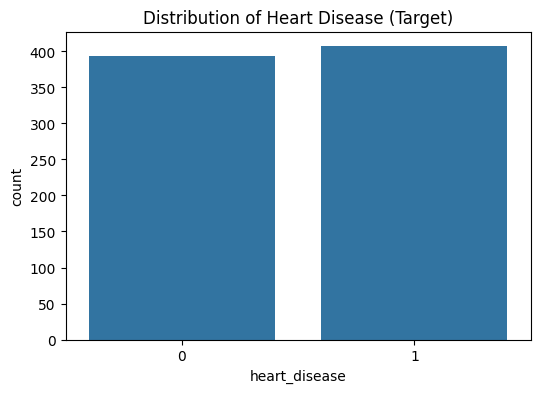

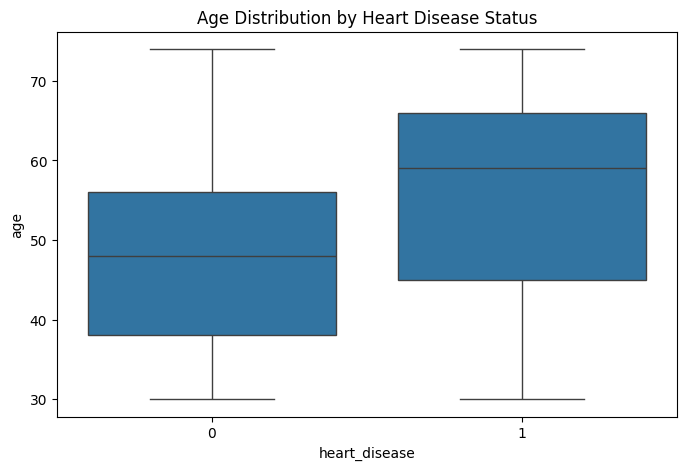

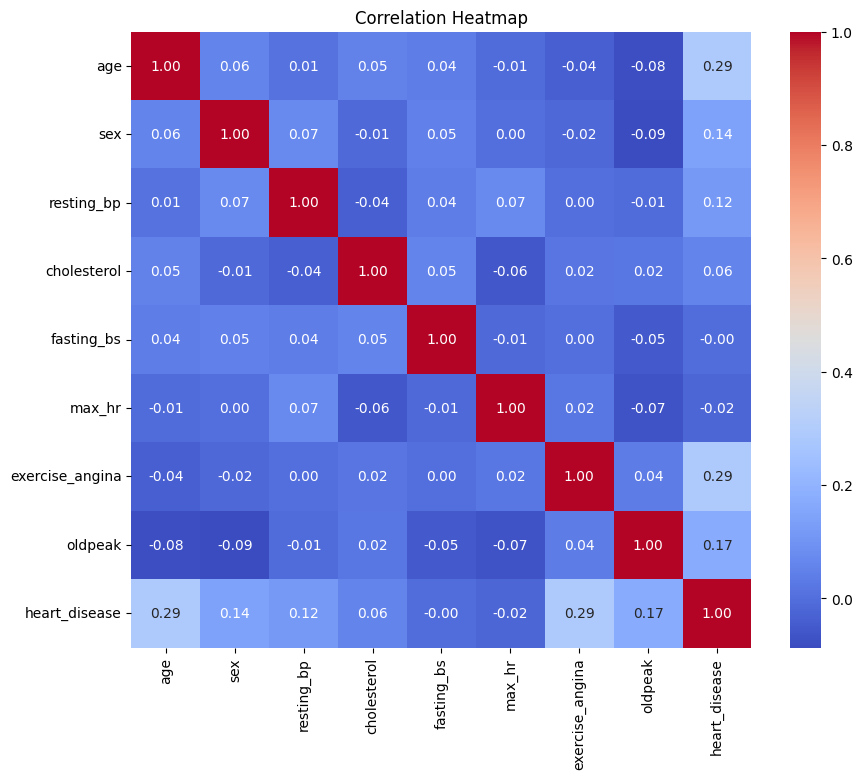

In [2]:
# Plot 1: Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# Plot 2: Age vs Heart Disease
plt.figure(figsize=(8, 5))
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.show()

# Plot 3: Correlation Heatmap
plt.figure(figsize=(10, 8))
# Only correlate numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Cell 3: Markdown Cell (Interpretation)
Interpretation:

Target Distribution: The classes appear relatively balanced, though we will use stratification to ensure the split is even.

Age vs Disease: Older patients seem slightly more likely to have heart disease based on the boxplot medians.

Correlation: Features like oldpeak and age show a moderate positive correlation with the target, while max_hr shows a negative correlation.

In [6]:
# 1. Handle missing values
df = df.dropna()

# 2. Automatically find categorical columns (text-based columns)
# This prevents the KeyError because it only picks columns that actually exist
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# 3. Apply one-hot encoding
df = pd.get_dummies(df, columns=cat_cols)

# 4. Separate features and target
# Make sure 'heart_disease' is spelled exactly like it is in your CSV
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6. Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete! Data is ready for the models.")

Preprocessing complete! Data is ready for the models.


In [7]:
# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Fit models
dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [8]:
models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))
    print("-" * 30)

--- Decision Tree ---
Confusion Matrix:
 [[50 22]
 [17 60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72        72
           1       0.73      0.78      0.75        77

    accuracy                           0.74       149
   macro avg       0.74      0.74      0.74       149
weighted avg       0.74      0.74      0.74       149

------------------------------
--- Random Forest ---
Confusion Matrix:
 [[53 19]
 [15 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76        72
           1       0.77      0.81      0.78        77

    accuracy                           0.77       149
   macro avg       0.77      0.77      0.77       149
weighted avg       0.77      0.77      0.77       149

------------------------------
--- Gradient Boosting ---
Confusion Matrix:
 [[57 15]
 [12 65]]

Classification Report:
               precision  

In [9]:
# Tuning Random Forest (assuming it or GB performs best)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
tuned_preds = grid_search.best_estimator_.predict(X_test_scaled)
print("\nTuned Model Report:\n", classification_report(y_test, tuned_preds))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

Tuned Model Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76        72
           1       0.77      0.81      0.78        77

    accuracy                           0.77       149
   macro avg       0.77      0.77      0.77       149
weighted avg       0.77      0.77      0.77       149

